Kent Lin Chan

20202132

Se usó python 3.14.2

Pregunta 1
(a) Defina la secuencia hlp[n] en Python para n ∈ [−20,20] y grafíquela usando stem

Importar librerias

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from math import *
np.__version__

'2.4.4'

In [8]:
n= np.arange(-20,21)
wc=pi/2
print(n)

[-20 -19 -18 -17 -16 -15 -14 -13 -12 -11 -10  -9  -8  -7  -6  -5  -4  -3
  -2  -1   0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15
  16  17  18  19  20]


Text(0, 0.5, 'hlp(n)')

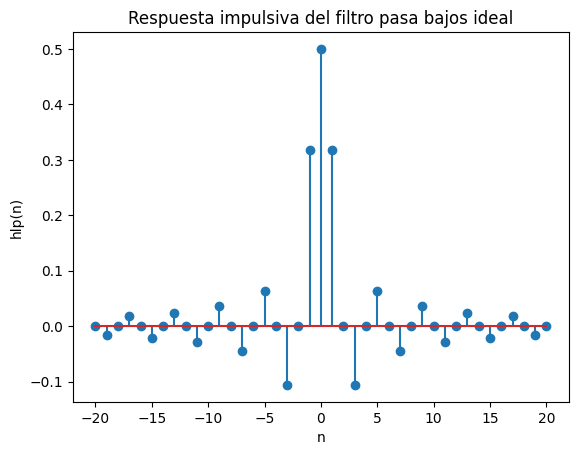

In [9]:
hlp=wc/pi*np.sinc(wc*n/pi)  #sinc(x) = sin(pi*x)/(pi*x)

plt.stem(n,hlp)
plt.title("Respuesta impulsiva del filtro pasa bajos ideal")
plt.xlabel('n')
plt.ylabel('hlp(n)')

(b) Implemente la función dtft(x, n, omega) que calcule la Transformada de Fourier
en Tiempo Discreto (DTFT):

In [10]:
def dtft(x,n,omega):
    """Calcula la DTFT de una señal x[n] dada su secuencia n y el vector de frecuencias omega.
    """
    Xw = np.exp(-1j * np.outer(omega, n)) #np.outer da a[i]*b[j] para cada i,j
    Xw = np.dot(Xw, x)
    return Xw


(c) Aplique la función dtft a hlp[n] considerando 1000 puntos de frecuencia en el rango
ω ∈ [−2π, 2π] rad/muestra y grafique la parte real de Hlp(ejω) con etiquetas en
múltiplos de π en el eje horizontal. Comente sus resultados.

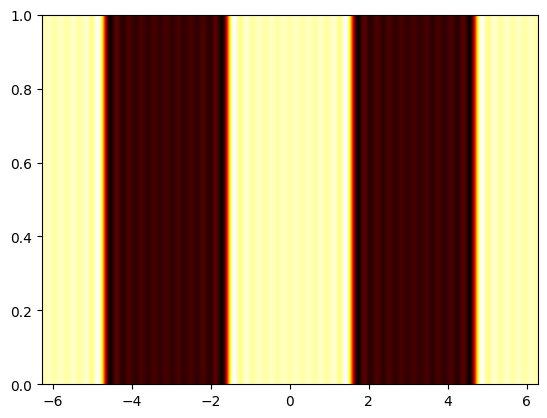

In [11]:
omega= np.linspace(-2*pi,2*pi,1000)
Hlp=dtft(hlp,n,omega)
plt.imshow(np.real(Hlp).reshape(1, -1), aspect='auto', cmap='hot', extent=(-2*pi, 2*pi, 0, 1)) 
#Se muestra una imagen donde la parte más oscura indican las bandas de rechazo y las partes más claras indican las bandas de paso.

Plotear la parte real de Hlp(ejω)

<>:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\kentj\AppData\Local\Temp\ipykernel_5092\3052232458.py:5: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('$\omega$')
C:\Users\kentj\AppData\Local\Temp\ipykernel_5092\3052232458.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


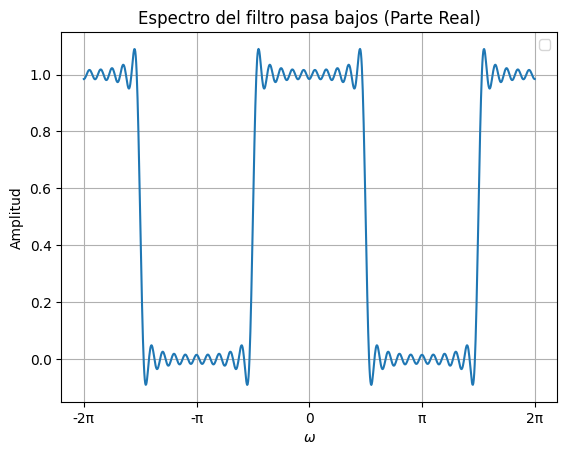

In [12]:
plt.figure()
plt.plot(omega, np.real(Hlp))
plt.title('Espectro del filtro pasa bajos (Parte Real)')
plt.xticks([-2*pi, -pi, 0, pi, 2*pi], ['-2π', '-π', '0', 'π', '2π'])
plt.xlabel('$\omega$')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()
plt.show()

Se evidencia que la DTFT de hlp[n] se asemeja a una función de pulsos rectangulares con periodo 2pi, lo que es consistente con el hecho de que hlp[n] es la respuesta impulsiva de un filtro pasa bajos ideal. Donde el ancho de banda total del pulso rectangular es pi. Esto significa que el filtro pasa bajos ideal tiene una frecuencia de corte de pi/2 rad/muestra, lo que corresponde a la mitad de la frecuencia de Nyquist el cual es pi.
Además se observa que hay el fenómeno de Gibbs, el cual se manifiesta como oscilaciones alrededor de las discontinuidades en la función de frecuencia. Estas oscilaciones son más pronunciadas cerca de las frecuencias de corte y disminuyen a medida que nos alejamos de ellas.